# Exoplanet Candidate Classification using NASA Kepler Data

NASA’s Kepler mission has generated thousands of Kepler Objects of Interest (KOIs), each of which may be a planet candidate or a false positive. Manual vetting of such candidates is time-consuming and requires expert knowledge.  

In this project, we build machine learning models (Logistic Regression, Random Forest, XGBoost) to classify KOIs as **planet candidates** or **false positives** based on their astrophysical features.  

In [2]:
import os, glob
import pandas as pd
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 200)

data_dir = '/kaggle/input/kepler-exoplanet-search-results'
print("Dataset folder exists?", os.path.exists(data_dir))
print("Files there:", os.listdir(data_dir) if os.path.exists(data_dir) else "NO FOLDER")

Dataset folder exists? True
Files there: ['cumulative.csv']


In [3]:
csvs = glob.glob(os.path.join(data_dir, '*.csv'))
if len(csvs) == 0:
    raise FileNotFoundError("No CSV found in dataset folder. Did you add the dataset to the notebook?")
csv_path = csvs[0]
print("Using CSV:", csv_path)

Using CSV: /kaggle/input/kepler-exoplanet-search-results/cumulative.csv


In [4]:
df = pd.read_csv(csv_path)
print("\nDataframe shape:", df.shape)


Dataframe shape: (9564, 50)


In [5]:
#columns and head
print("\nColumns (first 80):")
print(list(df.columns)[:80])

print("\n--- df.head() ---")
print(df.head().to_string(index=False))


Columns (first 80):
['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition', 'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth', 'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1', 'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol', 'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad', 'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag']

--- df.head() ---
 rowid    kepid kepoi_name  kepler_name koi_disposition koi_pdisposition  koi_score  koi_fpflag_nt  koi_fpflag_ss  koi_fpflag_co  koi_fpflag_ec  koi_period  ko

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [6]:
print("\n dtypes & non-null counts (first 60 cols)")
print(df.iloc[:, :60].info())


 dtypes & non-null counts (first 60 cols)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   object 
 3   kepler_name        2294 non-null   object 
 4   koi_disposition    9564 non-null   object 
 5   koi_pdisposition   9564 non-null   object 
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-n

In [7]:
for col in ['koi_disposition', 'koi_score', 'kepid', 'kepoi_name', 'koi_prad', 'koi_period', 'koi_teq', 'koi_insol']:
    if col in df.columns:
        print(f"\nValue summary for '{col}':")
        if df[col].dtype.name.startswith('float') or df[col].dtype.name.startswith('int'):
            print(df[col].describe())
        else:
            print(df[col].value_counts(dropna=False).head(20))


Value summary for 'koi_disposition':
koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

Value summary for 'koi_score':
count    8054.000000
mean        0.480829
std         0.476928
min         0.000000
25%         0.000000
50%         0.334000
75%         0.998000
max         1.000000
Name: koi_score, dtype: float64

Value summary for 'kepid':
count    9.564000e+03
mean     7.690628e+06
std      2.653459e+06
min      7.574500e+05
25%      5.556034e+06
50%      7.906892e+06
75%      9.873066e+06
max      1.293514e+07
Name: kepid, dtype: float64

Value summary for 'kepoi_name':
kepoi_name
K00752.01    1
K05669.01    1
K05789.01    1
K05790.01    1
K05791.01    1
K05792.01    1
K05793.01    1
K05794.01    1
K05795.01    1
K05415.01    1
K05416.01    1
K05417.01    1
K05418.01    1
K05419.01    1
K05421.01    1
K05422.01    1
K05543.01    1
K05788.01    1
K05668.01    1
K05408.01    1
Name: count, dtype: int64

Value summary fo

In [8]:
missing_frac = df.isna().mean().sort_values(ascending=False)
print("\nTop 25 columns by missing fraction:")
print(missing_frac.head(25))


Top 25 columns by missing fraction:
koi_teq_err2         1.000000
koi_teq_err1         1.000000
kepler_name          0.760142
koi_score            0.157884
koi_steff_err2       0.050502
koi_srad_err2        0.048934
koi_srad_err1        0.048934
koi_slogg_err2       0.048934
koi_slogg_err1       0.048934
koi_steff_err1       0.048934
koi_depth_err2       0.047470
koi_time0bk_err2     0.047470
koi_duration_err2    0.047470
koi_duration_err1    0.047470
koi_impact_err2      0.047470
koi_impact_err1      0.047470
koi_period_err1      0.047470
koi_time0bk_err1     0.047470
koi_period_err2      0.047470
koi_depth_err1       0.047470
koi_prad_err2        0.037955
koi_teq              0.037955
koi_prad_err1        0.037955
koi_prad             0.037955
koi_impact           0.037955
dtype: float64


In [9]:
print("\nNumeric summary (describe):")
print(df.select_dtypes(include=['number']).describe().T.head(30))


Numeric summary (describe):
                    count          mean           std            min           25%           50%           75%           max
rowid              9564.0  4.782500e+03  2.761033e+03       1.000000  2.391750e+03  4.782500e+03  7.173250e+03  9.564000e+03
kepid              9564.0  7.690628e+06  2.653459e+06  757450.000000  5.556034e+06  7.906892e+06  9.873066e+06  1.293514e+07
koi_score          8054.0  4.808294e-01  4.769285e-01       0.000000  0.000000e+00  3.340000e-01  9.980000e-01  1.000000e+00
koi_fpflag_nt      9564.0  1.882058e-01  3.908968e-01       0.000000  0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00
koi_fpflag_ss      9564.0  2.315977e-01  4.218753e-01       0.000000  0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00
koi_fpflag_co      9564.0  1.948975e-01  3.961425e-01       0.000000  0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00
koi_fpflag_ec      9564.0  1.200335e-01  3.250176e-01       0.000000  0.000000e+00  0.000000e+00

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [10]:
wanted = ['kepid','kepoi_name','koi_disposition','koi_score','koi_prad','koi_period','koi_depth','koi_duration','koi_impact','koi_teq','koi_insol']
present = [c for c in wanted if c in df.columns]
print("\nShowing sample rows for key columns (if present):", present)
if present:
    print(df[present].head(20).to_string(index=False))
else:
    print("None of the 'wanted' columns found in dataframe.")


Showing sample rows for key columns (if present): ['kepid', 'kepoi_name', 'koi_disposition', 'koi_score', 'koi_prad', 'koi_period', 'koi_depth', 'koi_duration', 'koi_impact', 'koi_teq', 'koi_insol']
   kepid kepoi_name koi_disposition  koi_score  koi_prad  koi_period  koi_depth  koi_duration  koi_impact  koi_teq  koi_insol
10797460  K00752.01       CONFIRMED      1.000      2.26    9.488036      615.8       2.95750       0.146    793.0      93.59
10797460  K00752.02       CONFIRMED      0.969      2.83   54.418383      874.8       4.50700       0.586    443.0       9.11
10811496  K00753.01  FALSE POSITIVE      0.000     14.60   19.899140    10829.0       1.78220       0.969    638.0      39.30
10848459  K00754.01  FALSE POSITIVE      0.000     33.46    1.736952     8079.2       2.40641       1.276   1395.0     891.96
10854555  K00755.01       CONFIRMED      1.000      2.75    2.525592      603.3       1.65450       0.701   1406.0     926.16
10872983  K00756.01       CONFIRMED      1.0

In [11]:
if 'kepid' in df.columns:
    print("\nUnique kepid count:", df['kepid'].nunique())


Unique kepid count: 8214


In [12]:
#Preprocessing & train/test split (binary target)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# df is assumed loaded from Step 1
print("Original shape:", df.shape)

# 1) Build binary target: FALSE POSITIVE -> 0, else -> 1
y = df['koi_disposition'].map(lambda x: 0 if str(x).strip().upper() == 'FALSE POSITIVE' else 1)
print("Target distribution (overall):")
print(y.value_counts())

Original shape: (9564, 50)
Target distribution (overall):
koi_disposition
0    5023
1    4541
Name: count, dtype: int64


In [13]:
# Drop columns we won't use / that leak / text identifiers / error columns
drop_cols = []
# identifiers/text
for c in ['rowid','kepid','kepoi_name','kepler_name','koi_tce_delivname','koi_pdisposition']:
    if c in df.columns:
        drop_cols.append(c)
# drop koi_score to avoid leakage
if 'koi_score' in df.columns:
    drop_cols.append('koi_score')
# drop all columns that look like error columns (_err1/_err2) because they are duplicate error bounds
err_cols = [c for c in df.columns if ('_err1' in c) or ('_err2' in c) or c.endswith('_err1') or c.endswith('_err2') or '_err' in c and c not in ['koi_kepmag']] 
# (the condition above is broad — we'll filter for exact substrings)
err_cols = [c for c in err_cols if c in df.columns]
drop_cols += err_cols

# drop columns with >60% missingness
missing_frac = df.isna().mean()
high_miss = missing_frac[missing_frac > 0.60].index.tolist()
drop_cols += high_miss

# make unique and only keep those that exist
drop_cols = sorted(list({c for c in drop_cols if c in df.columns}))

print("\nColumns to drop ({}):\n{}".format(len(drop_cols), drop_cols))


Columns to drop (29):
['kepid', 'kepler_name', 'kepoi_name', 'koi_depth_err1', 'koi_depth_err2', 'koi_duration_err1', 'koi_duration_err2', 'koi_impact_err1', 'koi_impact_err2', 'koi_insol_err1', 'koi_insol_err2', 'koi_pdisposition', 'koi_period_err1', 'koi_period_err2', 'koi_prad_err1', 'koi_prad_err2', 'koi_score', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad_err1', 'koi_srad_err2', 'koi_steff_err1', 'koi_steff_err2', 'koi_tce_delivname', 'koi_teq_err1', 'koi_teq_err2', 'koi_time0bk_err1', 'koi_time0bk_err2', 'rowid']


In [14]:
df_proc = df.drop(columns=drop_cols).copy()
print("\nShape after dropping:", df_proc.shape)


Shape after dropping: (9564, 21)


In [15]:
X = df_proc.select_dtypes(include=[np.number]).copy()
print("\nNumeric feature count (before NA handling):", X.shape[1])


Numeric feature count (before NA handling): 20


In [16]:
# Remove any columns that are all constant or near-constant (optional)
nunique = X.nunique()
const_cols = nunique[nunique <= 1].index.tolist()
if const_cols:
    X.drop(columns=const_cols, inplace=True)
    print("Dropped constant cols:", const_cols)

In [17]:
# Impute numeric missing values with medians (simple, robust)
medians = X.median()
X = X.fillna(medians)

In [18]:
#Detect highly skewed features and apply log1p with safe shifting if needed
skew_abs = X.skew().abs().sort_values(ascending=False)
print("\nTop 20 features by absolute skew (before transform):")
print(skew_abs.head(20))

# choose skew threshold (you can adjust later). We'll transform features with abs(skew) > 2
skew_thresh = 2.0
skewed_cols = skew_abs[skew_abs > skew_thresh].index.tolist()
print("\nColumns selected for log1p transform (abs(skew) > {}): {} ({} cols)".format(skew_thresh, skewed_cols, len(skewed_cols)))

# apply safe log1p: shift non-positive values to make them positive then log1p
shift_map = {}
for c in skewed_cols:
    mn = X[c].min()
    if not np.isfinite(mn):
        continue
    if mn <= 0:
        shift = 1.0 - mn
        X[c] = np.log1p(X[c] + shift)
        shift_map[c] = shift
    else:
        X[c] = np.log1p(X[c])
print("Applied log1p to skewed columns. Shift map (only if value >0):", shift_map)



Top 20 features by absolute skew (before transform):
koi_period          96.459326
koi_prad            53.137349
koi_insol           50.806469
koi_impact          23.967077
koi_srad            21.352723
koi_duration         5.928765
koi_model_snr        5.416992
koi_depth            5.370849
koi_tce_plnt_num     3.744736
koi_time0bk          3.682070
koi_teq              3.589774
koi_slogg            3.516030
koi_fpflag_ec        2.338618
koi_fpflag_nt        1.595610
koi_fpflag_co        1.540689
koi_fpflag_ss        1.272691
koi_kepmag           0.796126
koi_steff            0.755426
ra                   0.282209
dec                  0.169174
dtype: float64

Columns selected for log1p transform (abs(skew) > 2.0): ['koi_period', 'koi_prad', 'koi_insol', 'koi_impact', 'koi_srad', 'koi_duration', 'koi_model_snr', 'koi_depth', 'koi_tce_plnt_num', 'koi_time0bk', 'koi_teq', 'koi_slogg', 'koi_fpflag_ec'] (13 cols)
Applied log1p to skewed columns. Shift map (only if value >0): {'koi_insol':

In [19]:
print("\nFeature matrix shape after transforms:", X.shape)
print("Columns kept (first 50):", list(X.columns)[:50])



Feature matrix shape after transforms: (9564, 20)
Columns kept (first 50): ['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_steff', 'koi_slogg', 'koi_srad', 'ra', 'dec', 'koi_kepmag']


In [20]:
#Train/test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print("\\nTRAIN/TEST shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("y_test distribution:")
print(y_test.value_counts())


\nTRAIN/TEST shapes:
X_train: (7651, 20) X_test: (1913, 20)
y_train distribution:
koi_disposition
0    4018
1    3633
Name: count, dtype: int64
y_test distribution:
koi_disposition
0    1005
1     908
Name: count, dtype: int64


In [21]:
#Save some artifacts to disk for inspection 
X_train.head(3).to_csv('/kaggle/working/X_train_preview.csv', index=False)
X_test.head(3).to_csv('/kaggle/working/X_test_preview.csv', index=False)
print("\\nSaved small previews: /kaggle/working/X_train_preview.csv and X_test_preview.csv")

\nSaved small previews: /kaggle/working/X_train_preview.csv and X_test_preview.csv


In [22]:
#Baseline Models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve


In [23]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name=""):
    print(f"\n=== {model_name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    
    # Classification report
    print(classification_report(y_test, y_pred, digits=4))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.title(f"{model_name} - ROC Curve")
    plt.show()
    
    # PR Curve
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(rec, prec, label=f"{model_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.show()


=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.9850    0.9821    0.9836      1005
           1     0.9802    0.9835    0.9819       908

    accuracy                         0.9827      1913
   macro avg     0.9826    0.9828    0.9827      1913
weighted avg     0.9828    0.9827    0.9828      1913



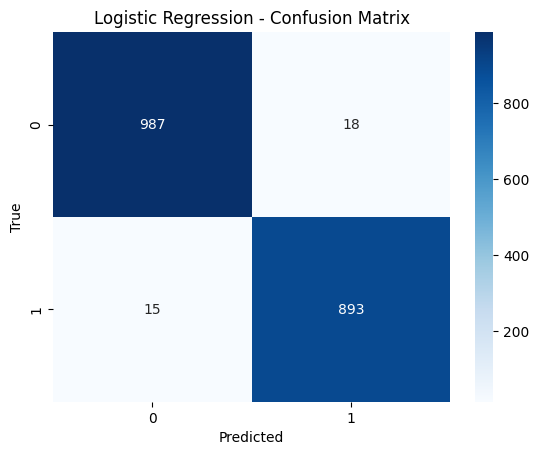

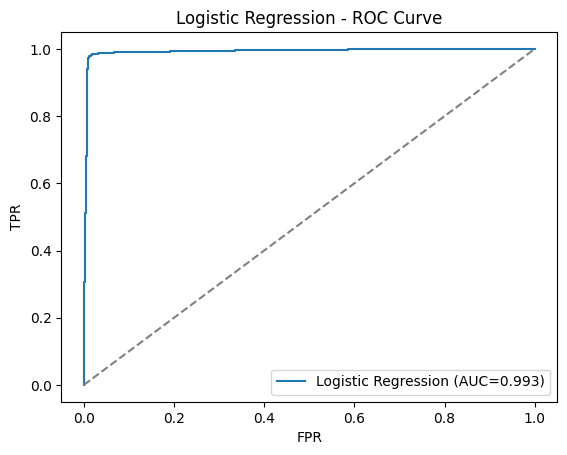

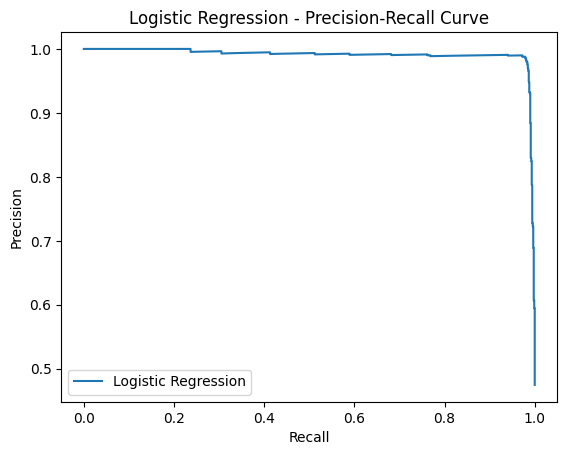

In [24]:
# 1. Logistic Regression (with scaling)
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=200, random_state=RANDOM_STATE))
])
evaluate_model(logreg_pipeline, X_train, y_train, X_test, y_test, "Logistic Regression")



=== Random Forest ===
              precision    recall  f1-score   support

           0     0.9831    0.9841    0.9836      1005
           1     0.9824    0.9813    0.9818       908

    accuracy                         0.9827      1913
   macro avg     0.9827    0.9827    0.9827      1913
weighted avg     0.9827    0.9827    0.9827      1913



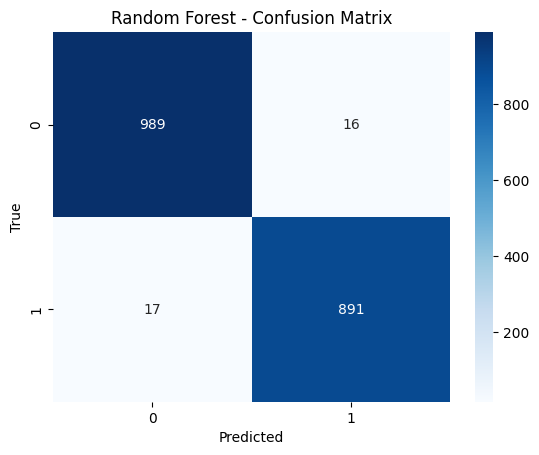

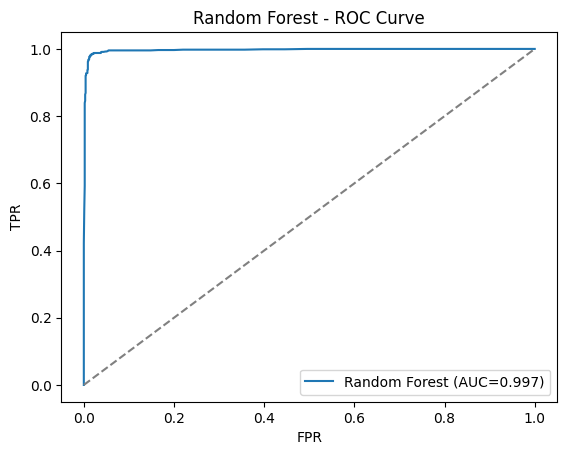

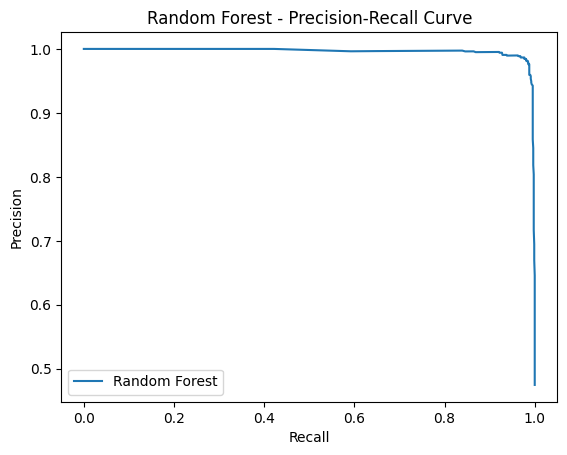

In [25]:
#2. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
evaluate_model(rf, X_train, y_train, X_test, y_test, "Random Forest")


=== XGBoost ===
              precision    recall  f1-score   support

           0     0.9860    0.9831    0.9846      1005
           1     0.9813    0.9846    0.9830       908

    accuracy                         0.9838      1913
   macro avg     0.9837    0.9838    0.9838      1913
weighted avg     0.9838    0.9838    0.9838      1913



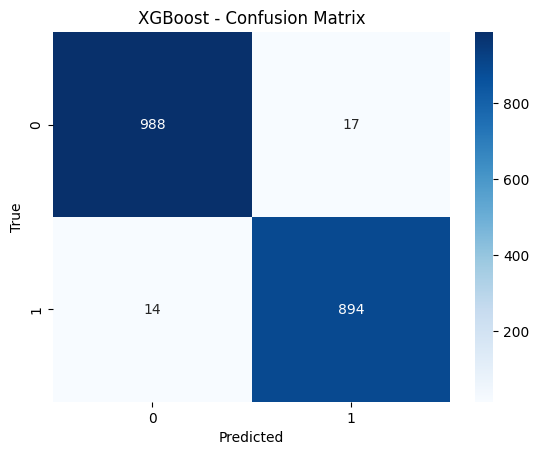

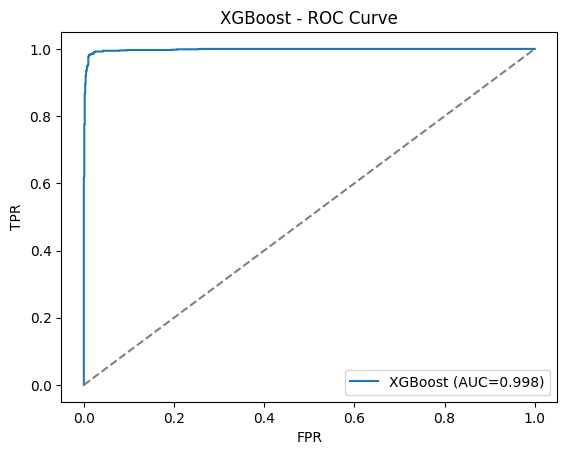

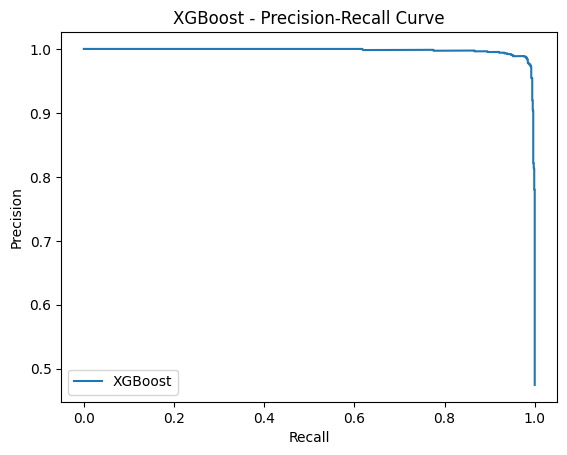

In [26]:
# 3. XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric="logloss"
)
evaluate_model(xgb, X_train, y_train, X_test, y_test, "XGBoost")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best RF Params: {'max_depth': 19, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 154}
Training Time:  203.03 seconds

=== RandomForest (Tuned) ===
              precision    recall  f1-score   support

           0     0.9840    0.9821    0.9831      1005
           1     0.9802    0.9824    0.9813       908

    accuracy                         0.9822      1913
   macro avg     0.9821    0.9822    0.9822      1913
weighted avg     0.9822    0.9822    0.9822      1913



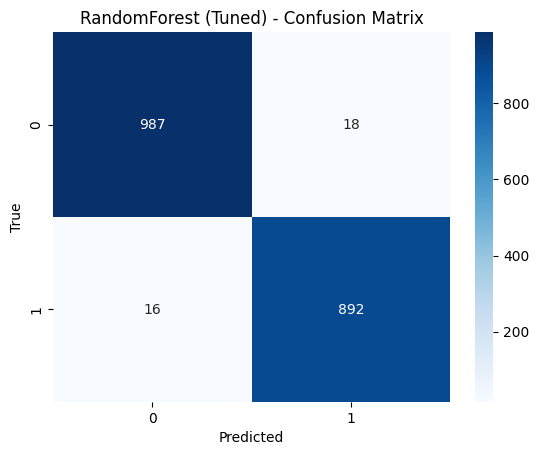

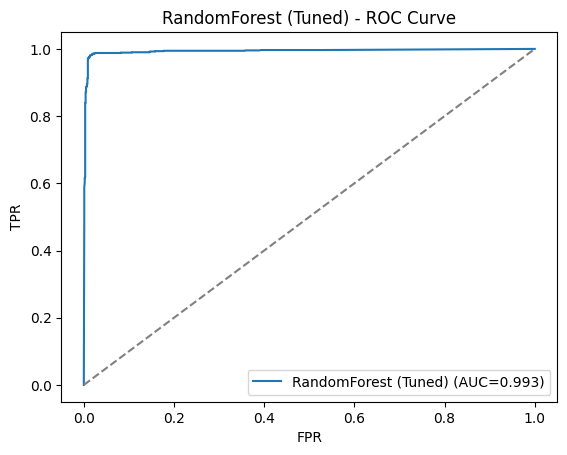

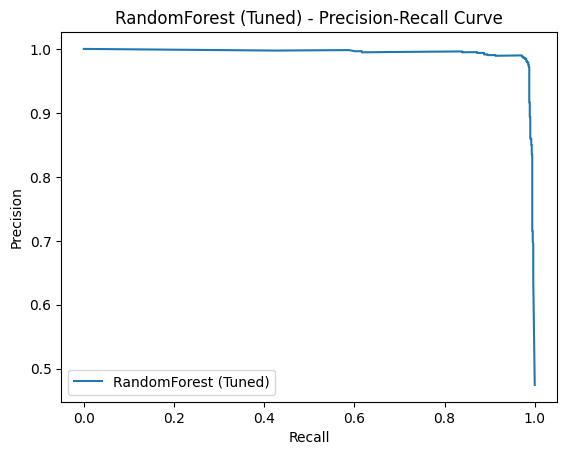

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import time

# --- Random Forest Tuning ---
rf_param_dist = {
    "n_estimators": randint(100, 600),
    "max_depth": randint(3, 20),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=rf_param_dist,
    n_iter=30,  # number of combinations to try
    cv=3,
    scoring="f1",
    verbose=2,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

start = time.time()
rf_random.fit(X_train, y_train)
end = time.time()

print("Best RF Params:", rf_random.best_params_)
print("Training Time: ", round(end-start,2), "seconds")
evaluate_model(rf_random.best_estimator_, X_train, y_train, X_test, y_test, "RandomForest (Tuned)")


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best XGB Params: {'colsample_bytree': 0.7888859700647797, 'learning_rate': 0.03391884918766034, 'max_depth': 5, 'n_estimators': 456, 'subsample': 0.8886918084659492}
Training Time:  33.48 seconds

=== XGBoost (Tuned) ===
              precision    recall  f1-score   support

           0     0.9851    0.9851    0.9851      1005
           1     0.9835    0.9835    0.9835       908

    accuracy                         0.9843      1913
   macro avg     0.9843    0.9843    0.9843      1913
weighted avg     0.9843    0.9843    0.9843      1913



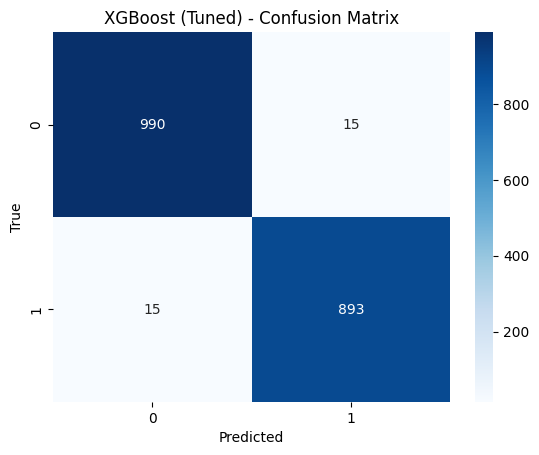

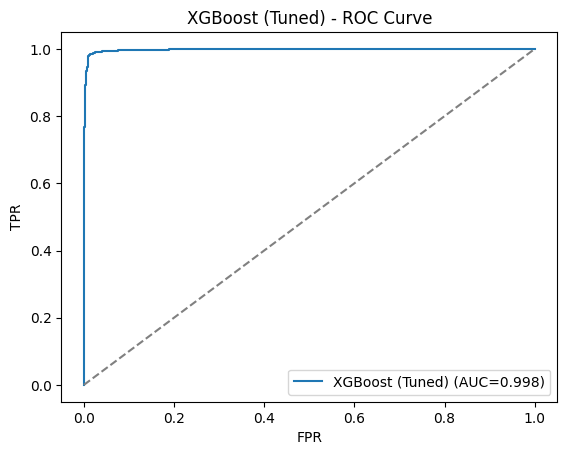

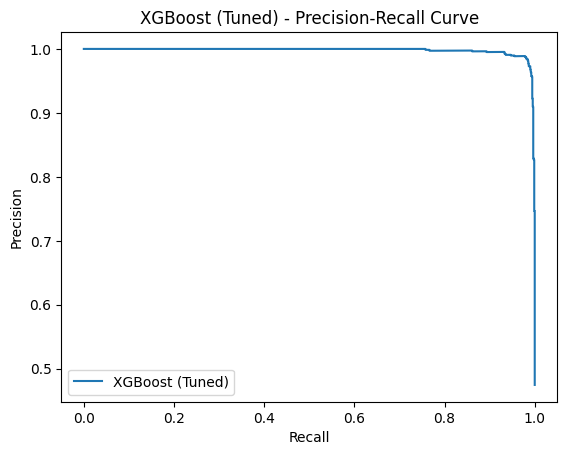

In [28]:
# --- XGBoost Tuning ---
xgb_param_dist = {
    "n_estimators": randint(200, 600),
    "learning_rate": uniform(0.01, 0.2),
    "max_depth": randint(3, 12),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4)
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", use_label_encoder=False),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=3,
    scoring="f1",
    verbose=2,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

start = time.time()
xgb_random.fit(X_train, y_train)
end = time.time()

print("Best XGB Params:", xgb_random.best_params_)
print("Training Time: ", round(end-start,2), "seconds")
evaluate_model(xgb_random.best_estimator_, X_train, y_train, X_test, y_test, "XGBoost (Tuned)")


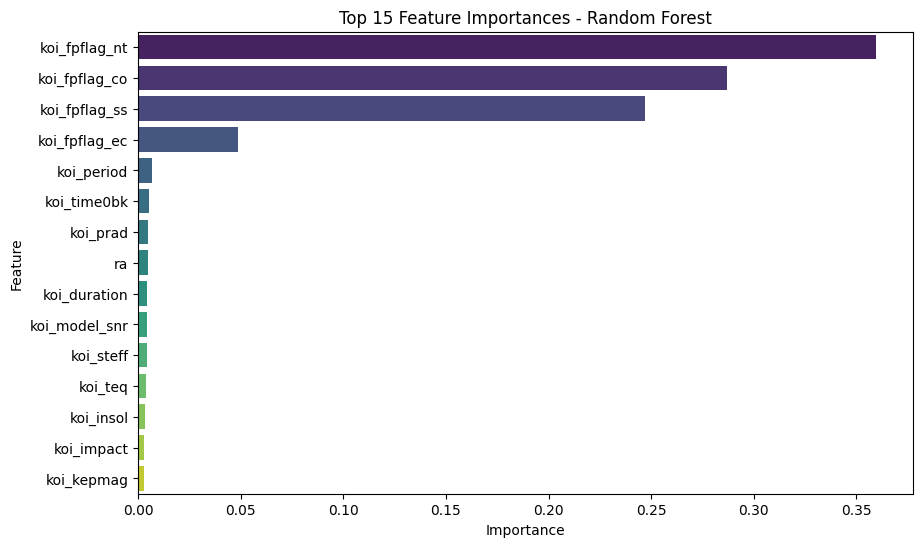

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from tuned RF
rf_best = rf_random.best_estimator_
importances = rf_best.feature_importances_

# Put into a DataFrame
feat_imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df.head(15), palette="viridis")
plt.title("Top 15 Feature Importances - Random Forest")
plt.show()


<Figure size 1000x600 with 0 Axes>

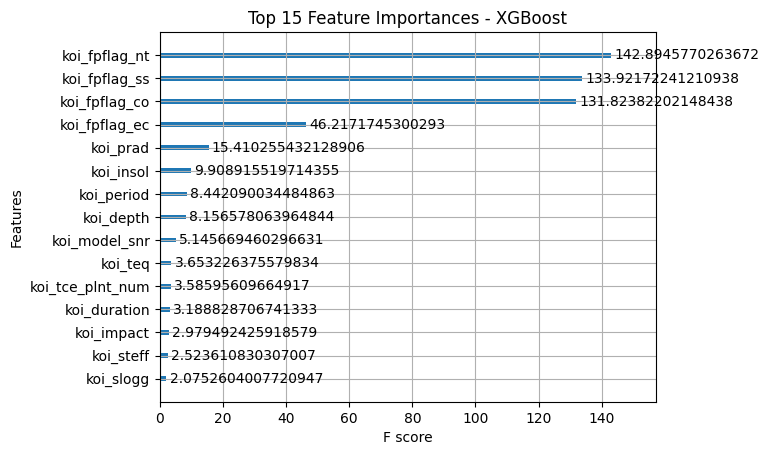

In [30]:
# Best tuned XGB model
xgb_best = xgb_random.best_estimator_

# Plot using XGBoost’s built-in plot
from xgboost import plot_importance

plt.figure(figsize=(10,6))
plot_importance(xgb_best, max_num_features=15, importance_type="gain")
plt.title("Top 15 Feature Importances - XGBoost")
plt.show()


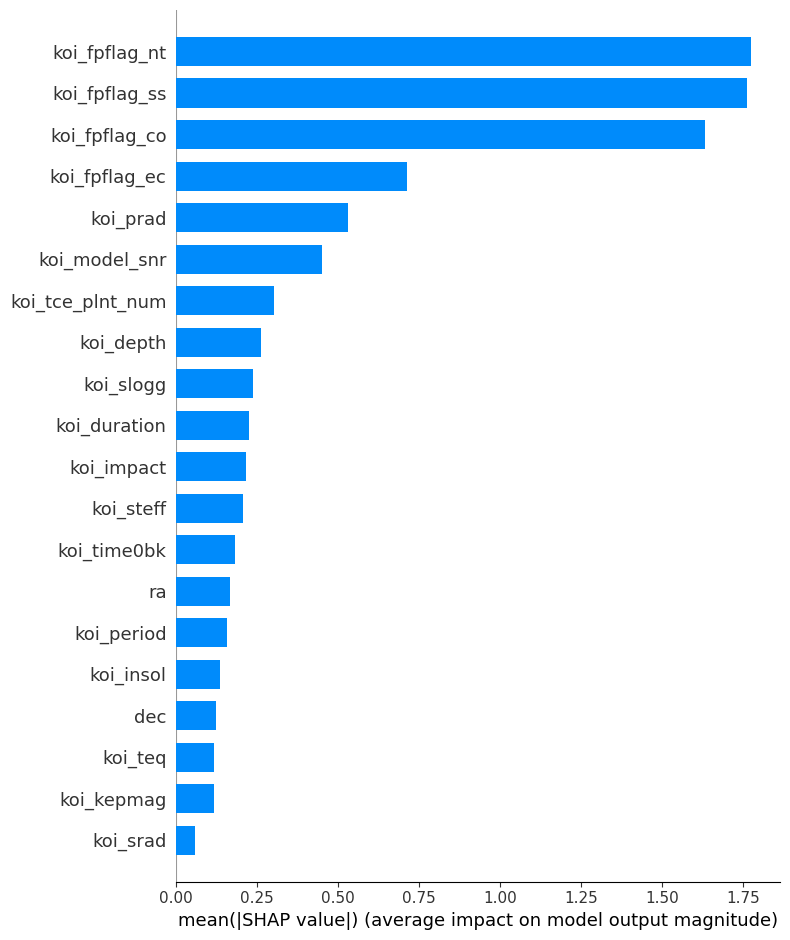

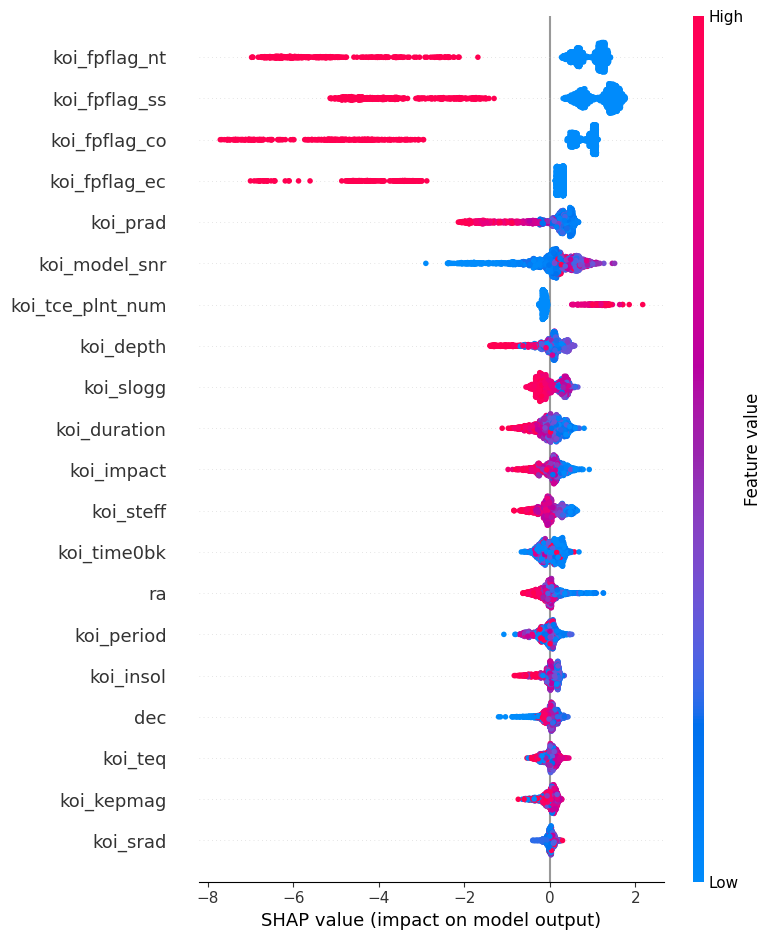

In [31]:
import shap

# Use TreeExplainer for RF or XGB
explainer = shap.TreeExplainer(xgb_best)   # or rf_best
shap_values = explainer.shap_values(X_test)

# Summary plot (global importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Detailed beeswarm plot (shows impact direction per feature)
shap.summary_plot(shap_values, X_test)


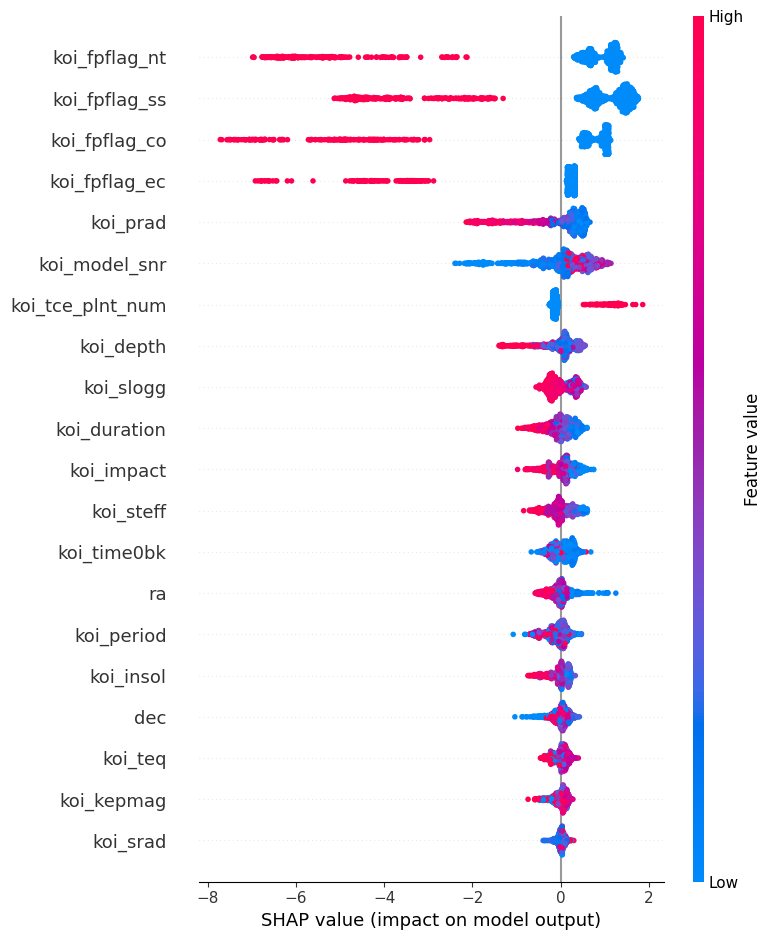

In [32]:
sample_X = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(sample_X)
shap.summary_plot(shap_values, sample_X)


In [37]:
print(y_test.value_counts(normalize=True))

koi_disposition
0    0.525353
1    0.474647
Name: proportion, dtype: float64


#  SHAP Explanations for Individual Predictions

Example: Candidate (Class 1)

In [33]:
# Pick one example from the test set
sample_idx = 0  # you can change this
sample_X = X_test.iloc[[sample_idx]]
sample_y = y_test.iloc[sample_idx]

print("True Label:", sample_y)


True Label: 1


In [36]:
# Use the trained XGBoost (or RandomForest) model
explainer = shap.TreeExplainer(xgb_best)  # or rf_best
shap_values = explainer.shap_values(sample_X)

# For classification models: shap_values is a list (per class)
# If binary, index 1 is usually the positive class (planet candidate)


* Red (pushing right → higher value → more likely class 1)
* Blue (pushing left → lower value → more likely class 0 / False Positive)

Each arrow shows how much a feature shifts the prediction away from the base value.

In [38]:
# Recompute SHAP values for a single sample
explainer = shap.TreeExplainer(xgb_best)   # or rf_best
shap_values = explainer.shap_values(sample_X)

# Force plot (works if shap_values is a 2D array)
shap.initjs()
shap.force_plot(
    explainer.expected_value,   # no [1] here
    shap_values[0],             # explanation for this single sample
    sample_X
)


* koi_depth = 5.614 (red) → strongly increases probability of being a candidate.

* koi_fpflag_ec = 0.6931 (red) → also pushes toward candidate.

* koi_duration = 0.8433, koi_time0bk = 4.916, etc. → add smaller positive pushes.

* dec = 38.11 (blue) → slightly pulls toward false positive, but not enough to outweigh the reds.

“The depth, duration, and flags look very planet-like, so I classify this as a planet candidate with high confidence.”

Example: False Positive (Class 0)

In [39]:
import matplotlib.pyplot as plt

# Pick a random index where the true label is 0 (FALSE POSITIVE)
idx0 = np.random.choice(y_test[y_test == 0].index)

# Extract the sample
sample_X0 = X_test.loc[[idx0]]
sample_y0 = y_test.loc[idx0]

# Explain this sample with SHAP
shap_values0 = explainer.shap_values(sample_X0)

# Force plot
shap.initjs()
shap.force_plot(
    explainer.expected_value,     # base value
    shap_values0[0],              # SHAP values for this sample
    sample_X0                     # feature values
)
